# Figure 2 — Accuracy per Domain: GLM-5.2 vs Kimi-K3

Per-domain accuracy for both models on two benchmarks:

- **SWE-bench Verified (n=500)** from `results/swe-bench-verified/2026-08-08-aggregated-500`,
  scored on the `resolved_ids` in each model's official summary. Grouped two ways —
  repository domains and the five-class solver-demand taxonomy — both shipped inside that
  bundle under `classifications/`.
- **Terminal-Bench 2.1 (n=89)** from `results/terminal-bench2.1/20260807-aggregated-89`,
  scored on the per-task verdicts in each model's `task_results.jsonl`, grouped by the
  six-class task taxonomy in `notebooks/tmp/terminal_bench_2_1_classification/`.

Claude Opus 5 is not included: it was only ever run on the n=150 SWE-bench pool, which now
lives in the deprecated `2026-07-regraded` bundle. Charting it here would put a 150-task score
next to a 500-task one.

No grouping has equal class sizes — Web & HTTP alone holds 240 of the 500 SWE-bench tasks, and
Terminal-Bench's C6 holds 25 of 89 — so every label carries its own solved/total count.

In [2]:
import importlib.metadata as md

print(md.version("matplotlib-inline"))
print([
      ep.name
      for ep in md.entry_points(group="matplotlib.backend")
])

0.2.2
['inline']


In [3]:
%matplotlib inline
import matplotlib.pyplot as plt

In [4]:
# Install missing packages into the active kernel, including uv environments without pip.
import importlib.util
import shutil
import subprocess
import sys

required = {'pandas': 'pandas>=2.2'}
missing = [package for module, package in required.items() if importlib.util.find_spec(module) is None]
if missing:
    print(f'Installing missing packages into {sys.executable}: {", ".join(missing)}')
    if uv := shutil.which('uv'):
        subprocess.check_call([uv, 'pip', 'install', '--python', sys.executable, *missing])
    else:
        if importlib.util.find_spec('pip') is None:
            subprocess.check_call([sys.executable, '-m', 'ensurepip', '--upgrade'])
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', *missing])
else:
    print('Notebook dependencies are already available in this kernel.')

Notebook dependencies are already available in this kernel.


# SWE-Bench-Verified

In [5]:
import json
from pathlib import Path

import pandas as pd
from matplotlib.patches import Patch

def find_repo(start):
    for candidate in (start, *start.parents):
        if (candidate / 'results/swe-bench-verified/2026-08-08-aggregated-500').exists():
            return candidate
    raise FileNotFoundError('Run this notebook from inside the agent-benchmark repository.')

REPO = find_repo(Path.cwd().resolve())
BUNDLE = REPO / 'results/swe-bench-verified/2026-08-08-aggregated-500'
POOL_PATH = BUNDLE / 'audit/instances_n500.txt'

# Both classifications ship with the bundle, one row per instance.
DOMAIN_PATH = BUNDLE / 'classifications/repository_domains/repository_domain_classifications_500.csv'
FINAL_TAXONOMY_PATH = BUNDLE / 'classifications/solver_demand_taxonomy/case_classifications_500.csv'

MODELS = {
    'GLM-5.2 xhigh': {
        'summary': BUNDLE / 'results/glm-5.2/xhigh_n500/official_summary.json',
        'color': '#2a78d6',
    },
    'Kimi-K3 max': {
        'summary': BUNDLE / 'results/kimi-k3/max_n500/official_summary.json',
        'color': '#eb6834',
    },
}

# Preserve the original Figure 2 top-to-bottom ordering.
DOMAIN_ORDER = ['Scientific & data', 'Dev tooling', 'Data-viz', 'Web & HTTP', 'Symbolic math']

## Recompute official scores by domain

The denominator comes only from the shared pool. A task counts as solved only when its ID appears in that model's official `resolved_ids`.

In [6]:
pool = POOL_PATH.read_text().split()
assert len(pool) == 500 and len(set(pool)) == 500

domain_map = pd.read_csv(DOMAIN_PATH, encoding='utf-8-sig', usecols=['case_id', 'domain'])
assert len(domain_map) == 500 and domain_map.case_id.is_unique
assert set(domain_map.case_id) == set(pool)
assert set(domain_map.domain) == set(DOMAIN_ORDER)

def load_resolved(path):
    summary = json.loads(path.read_text())
    resolved = summary.get('resolved_ids')
    if not isinstance(resolved, list):
        raise ValueError(f'No resolved_ids list in {path}')
    assert summary['total_instances'] == len(pool)
    assert summary['resolved_instances'] == len(resolved)
    return set(resolved), summary

def score_by_class(frame, resolved):
    """Solved and total per class, for whichever grouping `frame` carries in its `domain` column."""
    hits = frame.assign(hit=frame.case_id.isin(resolved))
    grouped = hits.groupby('domain', sort=False).hit.agg(['sum', 'count'])
    return [
        {
            'domain': domain,
            'resolved': int(row['sum']),
            'total': int(row['count']),
            'rate_pct': 100 * row['sum'] / row['count'],
        }
        for domain, row in grouped.iterrows()
    ]

rows = []
overall_rows = []
for model, config in MODELS.items():
    resolved, summary = load_resolved(config['summary'])
    rows.extend({'model': model, **score} for score in score_by_class(domain_map, resolved))
    overall_rows.append({
        'model': model, 'resolved': summary['resolved_instances'],
        'total': summary['total_instances'],
        'rate_pct': 100 * summary['resolved_instances'] / summary['total_instances'],
    })

scores = pd.DataFrame(rows)
overall = pd.DataFrame(overall_rows).set_index('model')
# Domains are unequal at n=500, so check the split covers the pool rather than asserting a size.
assert scores.groupby('model').total.sum().eq(500).all()
overall.style.format({'rate_pct': '{:.1f}%'})

,resolved,total,rate_pct
model,,,
GLM-5.2 xhigh,418,500,83.6%
Kimi-K3 max,469,500,93.8%


In [7]:
score_labels = scores.assign(
    score=scores.apply(lambda row: f"{row.rate_pct:.1f}% ({row.resolved}/{row.total})", axis=1)
).pivot(index='domain', columns='model', values='score')
score_labels[list(MODELS)]

model,GLM-5.2 xhigh,Kimi-K3 max
domain,,
Data-viz,83.3% (30/36),97.2% (35/36)
Dev tooling,82.2% (60/73),93.2% (68/73)
Scientific & data,85.5% (65/76),94.7% (72/76)
Symbolic math,84.0% (63/75),96.0% (72/75)
Web & HTTP,83.3% (200/240),92.5% (222/240)


## Figure 2 — grouped domain comparison

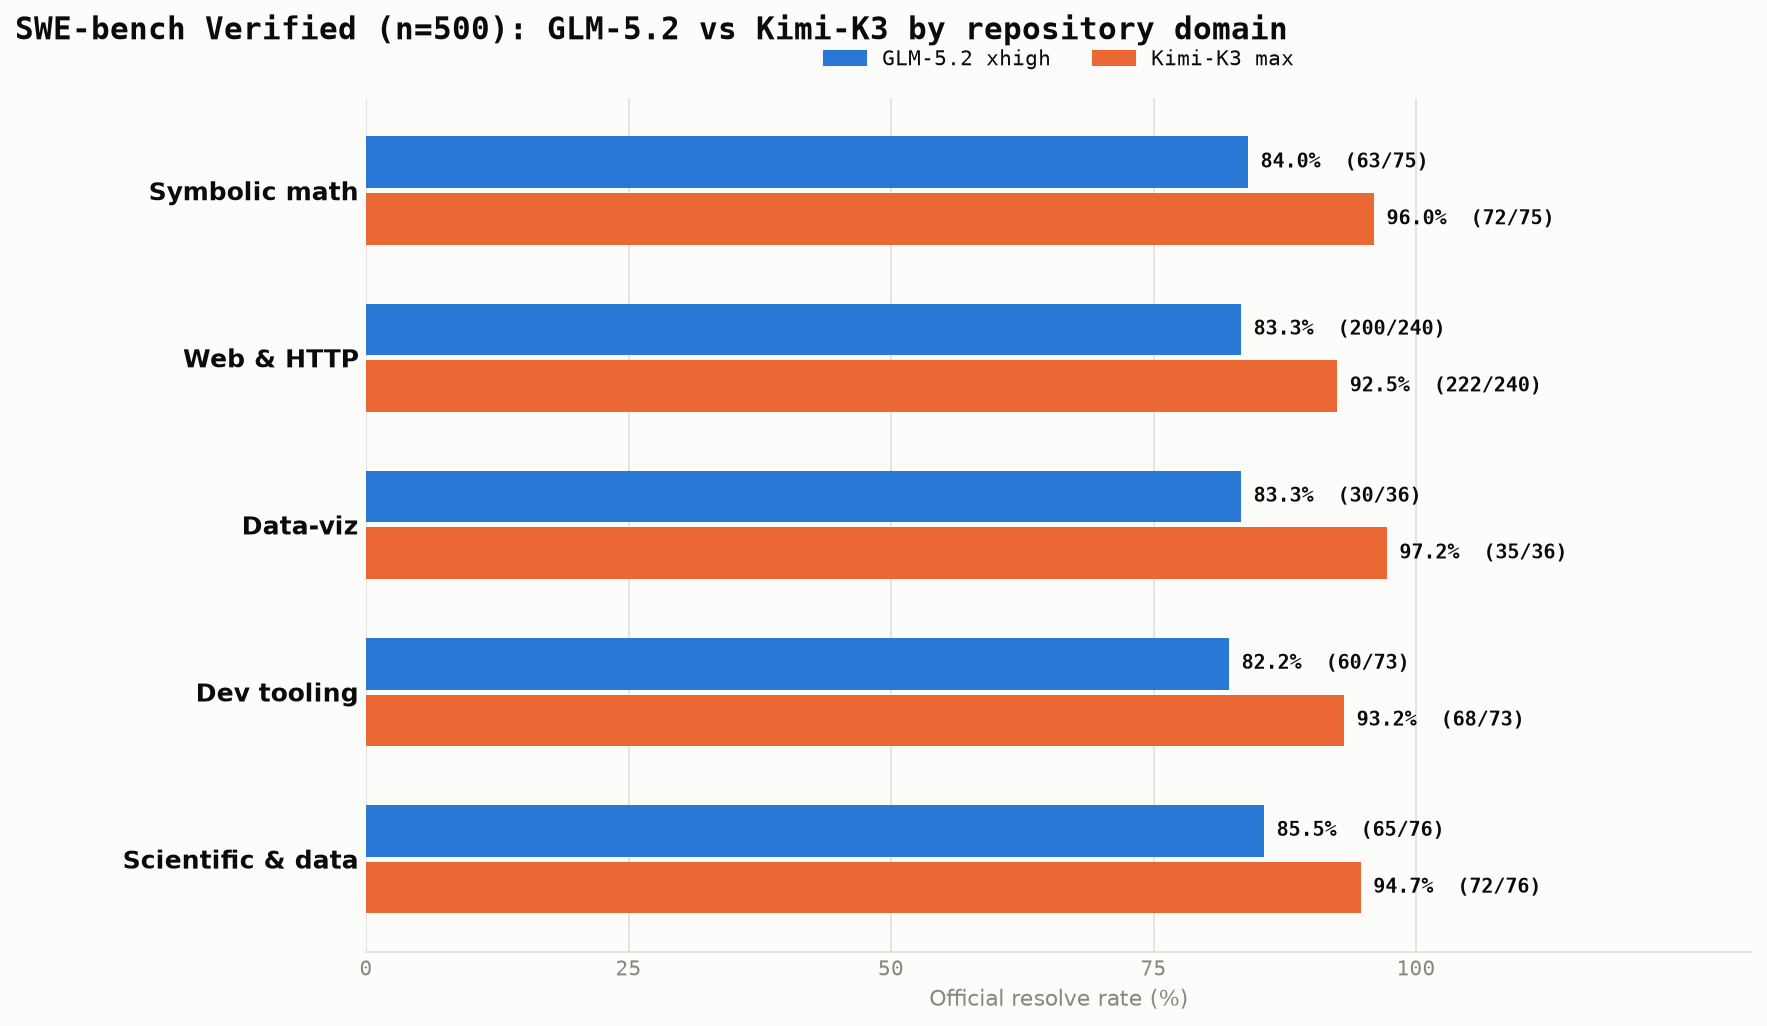

In [8]:
SURFACE = '#fcfcfb'; INK = '#0b0b0b'; MUTED = '#898781'; GRID = '#e1e0d9'
MONO = ['DejaVu Sans Mono', 'Menlo', 'monospace']

# barh draws the first item at the bottom, so DOMAIN_ORDER reads bottom-to-top here.
fig, ax = plt.subplots(figsize=(12, 7.4), dpi=150)
fig.patch.set_facecolor(SURFACE); ax.set_facecolor(SURFACE)

height = 0.34
offsets = [height / 2, -height / 2]
for yi, domain in enumerate(DOMAIN_ORDER):
    for (model, config), offset in zip(MODELS.items(), offsets):
        row = scores[(scores.model == model) & (scores.domain == domain)].iloc[0]
        ax.barh(yi + offset, row.rate_pct, height=height - 0.03, color=config['color'], zorder=3)
        ax.text(row.rate_pct + 1.2, yi + offset,
                f'{row.rate_pct:.1f}%  ({row.resolved}/{row.total})',
                va='center', ha='left', fontsize=9.5, color=INK,
                fontfamily=MONO, fontweight='bold')

ax.set_yticks(range(len(DOMAIN_ORDER)))
ax.set_yticklabels(DOMAIN_ORDER, fontsize=12, fontweight='bold', color=INK)
ax.set_xlim(0, 132); ax.set_xticks([0, 25, 50, 75, 100])
ax.set_xticklabels(['0', '25', '50', '75', '100'], fontsize=10, color=MUTED, fontfamily=MONO)
ax.set_xlabel('Official resolve rate (%)', fontsize=10.5, color=MUTED)
ax.xaxis.grid(True, color=GRID, lw=0.8, zorder=0); ax.set_axisbelow(True)
for side in ('top', 'right', 'left'): ax.spines[side].set_visible(False)
ax.spines['bottom'].set_color(GRID); ax.tick_params(length=0)
ax.legend(handles=[Patch(color=config['color'], label=model) for model, config in MODELS.items()],
          loc='lower center', bbox_to_anchor=(0.5, 1.01), ncol=2,
          frameon=False, fontsize=11, prop={'family': MONO}, labelcolor=INK)
fig.text(0.005, 0.955, 'SWE-bench Verified (n=500): GLM-5.2 vs Kimi-K3 by repository domain',
         fontsize=15, fontweight='bold', fontfamily=MONO, color=INK, va='top')
fig.subplots_adjust(left=0.20, right=0.97, top=0.88, bottom=0.11)

# out = REPO / 'notebooks/fig2_swebench_verified_repository_domains.png'
# fig.savefig(out, facecolor=SURFACE)
# print(f'saved -> {out}')
plt.show()

## Final five-class solver-demand comparison

The original repository domains are replaced with the final, mutually exclusive solver-demand taxonomy. Denominators vary by class, so every label shows both the percentage and solved/total count.

In [9]:
CLASS_LABELS = {
    'DATA_FIDELITY_PROBLEMS': 'Data fidelity problems',
    'TRACING_AND_OBSERVABILITY_PROBLEMS': 'Tracing & observability problems',
    'COMPATIBILITY_PROBLEMS': 'Compatibility problems',
    'RENDERING_AND_VISUAL_PROBLEMS': 'Rendering & visual problems',
    'PARSING_PROBLEMS': 'Parsing problems',
}
CLASS_ORDER = list(CLASS_LABELS.values())

taxonomy = pd.read_csv(FINAL_TAXONOMY_PATH, encoding='utf-8-sig', usecols=['case_id', 'primary_solver_demand_class'])
taxonomy['domain'] = taxonomy.primary_solver_demand_class.map(CLASS_LABELS)
assert len(taxonomy) == 500 and taxonomy.case_id.is_unique
assert taxonomy.domain.notna().all()
assert set(taxonomy.case_id) == set(pool)

taxonomy_rows = []
for model, config in MODELS.items():
    resolved, _ = load_resolved(config['summary'])
    taxonomy_rows.extend({'model': model, **score} for score in score_by_class(taxonomy, resolved))

taxonomy_scores = pd.DataFrame(taxonomy_rows)
taxonomy_scores.pivot(index='domain', columns='model', values='rate_pct').loc[CLASS_ORDER].round(1)

model,GLM-5.2 xhigh,Kimi-K3 max
domain,,
Data fidelity problems,84.4,92.4
Tracing & observability problems,84.7,97.6
Compatibility problems,87.1,93.1
Rendering & visual problems,77.3,95.5
Parsing problems,78.4,91.9


## Plot 1 — accuracy by final solver-demand class

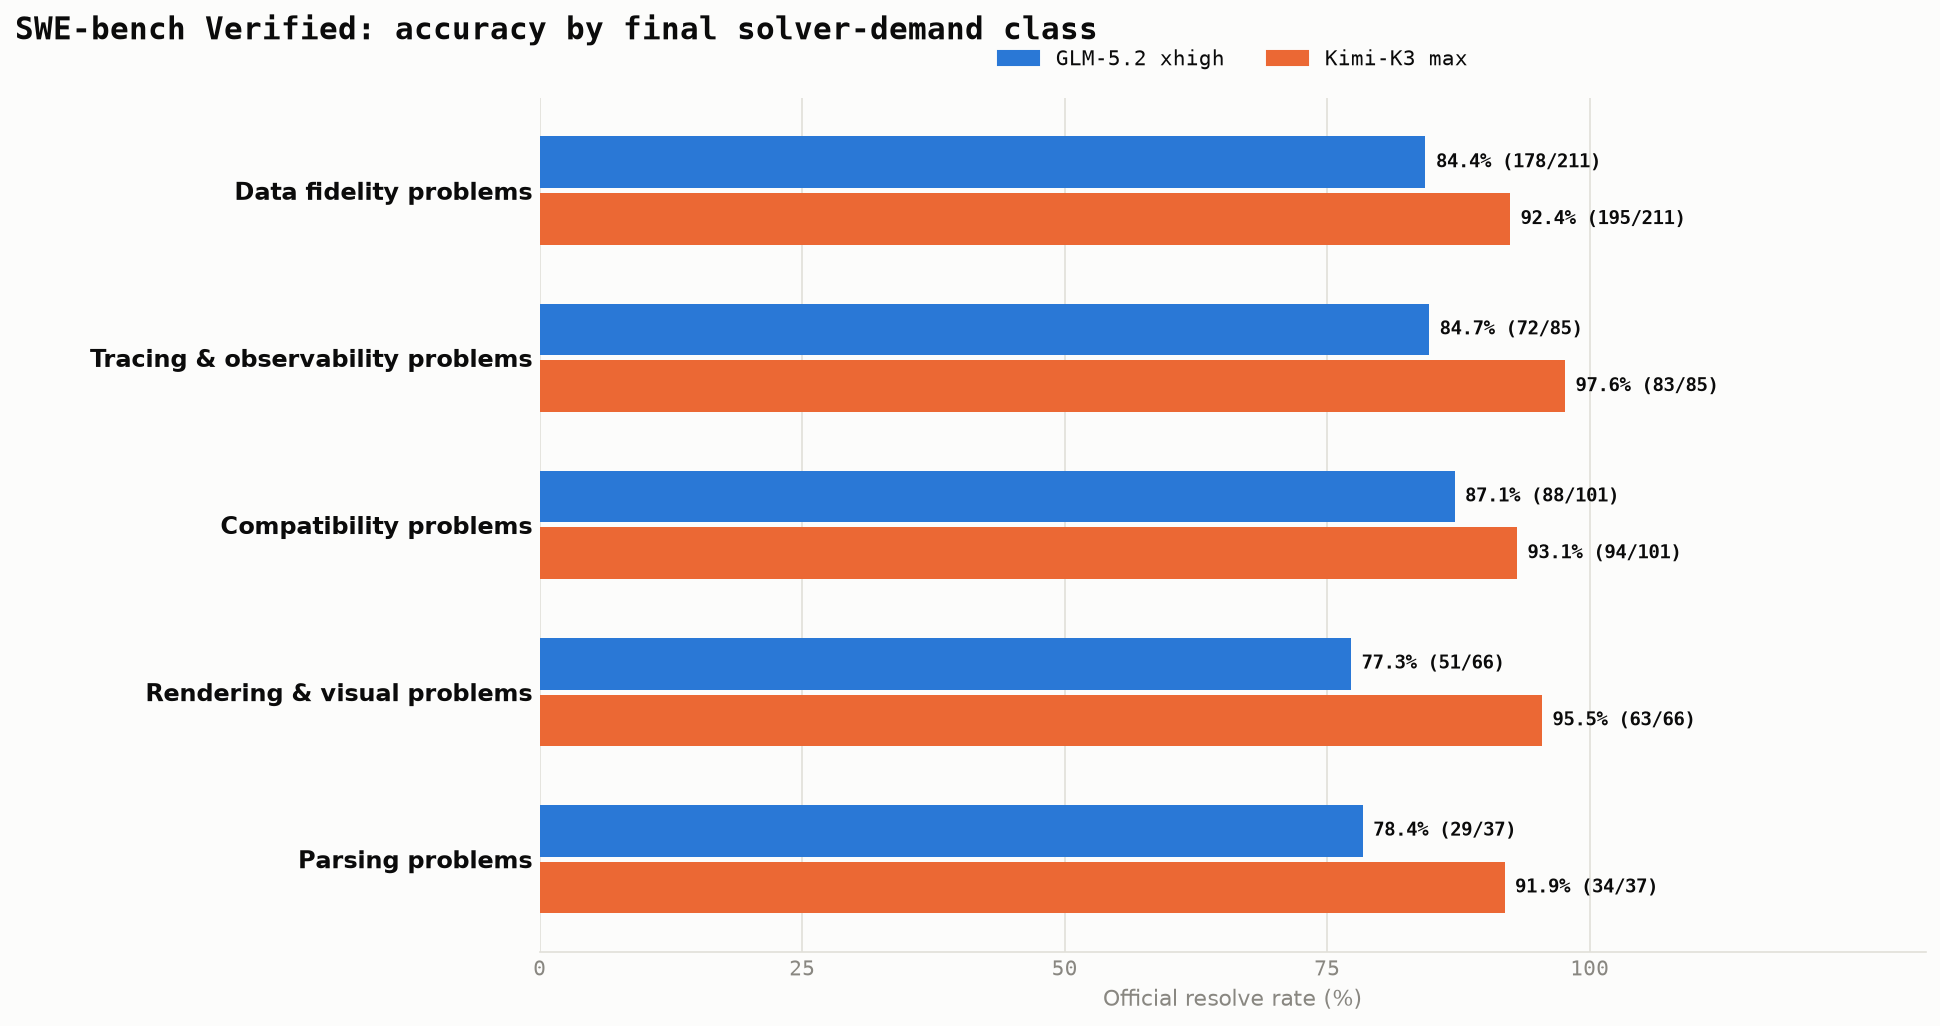

In [10]:
fig, ax = plt.subplots(figsize=(13.2, 7.4), dpi=150)
fig.patch.set_facecolor(SURFACE); ax.set_facecolor(SURFACE)

# Reverse because barh renders the first category at the bottom.
plot_domains = list(reversed(CLASS_ORDER))
height = 0.34
offsets = [height / 2, -height / 2]
for yi, domain in enumerate(plot_domains):
    for (model, config), offset in zip(MODELS.items(), offsets):
        row = taxonomy_scores[(taxonomy_scores.model == model) & (taxonomy_scores.domain == domain)].iloc[0]
        ax.barh(yi + offset, row.rate_pct, height=height - 0.03, color=config['color'], zorder=3)
        ax.text(row.rate_pct + 1.0, yi + offset,
                f'{row.rate_pct:.1f}% ({row.resolved}/{row.total})',
                va='center', ha='left', fontsize=9.1, color=INK,
                fontfamily=MONO, fontweight='bold')

ax.set_yticks(range(len(plot_domains)))
ax.set_yticklabels(plot_domains, fontsize=11.5, fontweight='bold', color=INK)
ax.set_xlim(0, 132); ax.set_xticks([0, 25, 50, 75, 100])
ax.set_xticklabels(['0', '25', '50', '75', '100'], fontsize=10, color=MUTED, fontfamily=MONO)
ax.set_xlabel('Official resolve rate (%)', fontsize=10.5, color=MUTED)
ax.xaxis.grid(True, color=GRID, lw=0.8, zorder=0); ax.set_axisbelow(True)
for side in ('top', 'right', 'left'): ax.spines[side].set_visible(False)
ax.spines['bottom'].set_color(GRID); ax.tick_params(length=0)
ax.legend(handles=[Patch(color=config['color'], label=model) for model, config in MODELS.items()],
          loc='lower center', bbox_to_anchor=(0.5, 1.01), ncol=2,
          frameon=False, fontsize=10.5, prop={'family': MONO}, labelcolor=INK)
fig.text(0.005, 0.955, 'SWE-bench Verified: accuracy by final solver-demand class',
         fontsize=15, fontweight='bold', fontfamily=MONO, color=INK, va='top')
fig.subplots_adjust(left=0.27, right=0.97, top=0.88, bottom=0.11)

# out = REPO / 'notebooks/fig2_swebench_verified_final_taxonomy_grouped_glm_5_2_vs_kimi_k3.png'
# fig.savefig(out, facecolor=SURFACE, bbox_inches='tight')
# print(f'saved -> {out}')
plt.show()

## Plot 2 — pairwise domain advantages

Bars show percentage-point margin. Left means the first named model leads; right means the second named model leads. Each panel uses the same scale.

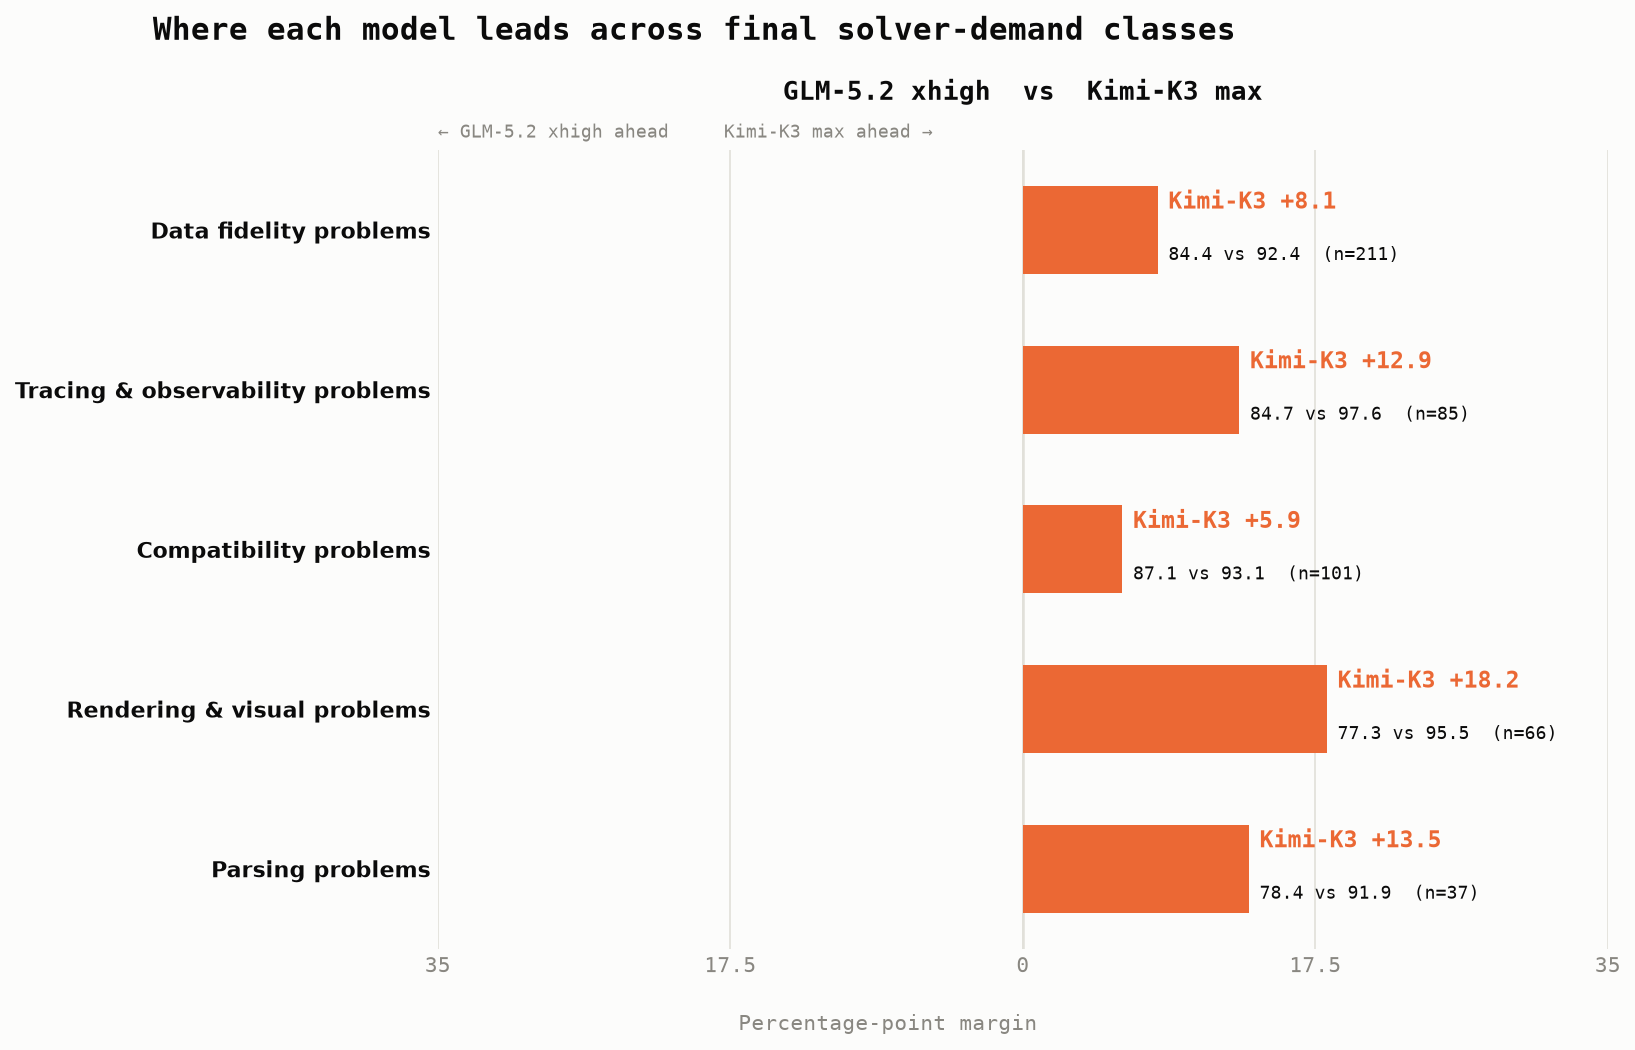

,comparison,domain,left_rate,right_rate,margin
0,GLM-5.2 xhigh vs Kimi-K3 max,Data fidelity problems,84.4,92.4,8.1
1,GLM-5.2 xhigh vs Kimi-K3 max,Tracing & observability problems,84.7,97.6,12.9
2,GLM-5.2 xhigh vs Kimi-K3 max,Compatibility problems,87.1,93.1,5.9
3,GLM-5.2 xhigh vs Kimi-K3 max,Rendering & visual problems,77.3,95.5,18.2
4,GLM-5.2 xhigh vs Kimi-K3 max,Parsing problems,78.4,91.9,13.5


In [11]:
def pairwise_frame(left_model, right_model):
    pivot = taxonomy_scores.pivot(index='domain', columns='model', values=['rate_pct', 'resolved', 'total'])
    rows = []
    for domain in CLASS_ORDER:
        left_rate = float(pivot.loc[domain, ('rate_pct', left_model)])
        right_rate = float(pivot.loc[domain, ('rate_pct', right_model)])
        rows.append({
            'domain': domain,
            'left_model': left_model, 'right_model': right_model,
            'left_rate': left_rate, 'right_rate': right_rate,
            'left_resolved': int(pivot.loc[domain, ('resolved', left_model)]),
            'right_resolved': int(pivot.loc[domain, ('resolved', right_model)]),
            'total': int(pivot.loc[domain, ('total', left_model)]),
            'margin': right_rate - left_rate,
        })
    return pd.DataFrame(rows)

comparisons = [
    ('GLM-5.2 xhigh', 'Kimi-K3 max'),
]
pairwise = {pair: pairwise_frame(*pair) for pair in comparisons}
max_margin = max(abs(frame.margin).max() for frame in pairwise.values())
# Leave enough horizontal room for the winner and score annotations beyond the longest bar.
axis_limit = max(10, int((max_margin + 12) // 5 + 1) * 5)

fig, axes = plt.subplots(1, 1, figsize=(10, 7.2), dpi=150, sharey=True, squeeze=False)
fig.patch.set_facecolor(SURFACE)
for ax, (left_model, right_model) in zip(axes[0], comparisons):
    frame = pairwise[(left_model, right_model)].iloc[::-1].reset_index(drop=True)
    ax.set_facecolor(SURFACE)
    for yi, row in frame.iterrows():
        margin = row.margin
        winner = right_model if margin > 0 else left_model if margin < 0 else 'Tie'
        color = MODELS[right_model]['color'] if margin > 0 else MODELS[left_model]['color'] if margin < 0 else MUTED
        ax.barh(yi, margin, height=0.55, color=color, zorder=3)
        label_x = margin + (0.65 if margin >= 0 else -0.65)
        ha = 'left' if margin >= 0 else 'right'
        margin_text = f'{winner.split()[0]} {abs(margin):+.1f}' if winner != 'Tie' else 'Tie 0.0'
        ax.text(label_x, yi + 0.10, margin_text, ha=ha, va='bottom', color=color,
                fontsize=11, fontweight='bold', fontfamily=MONO)
        ax.text(label_x, yi - 0.10,
                f'{row.left_rate:.1f} vs {row.right_rate:.1f}  (n={row.total})',
                ha=ha, va='top', color=INK, fontsize=8.8, fontfamily=MONO)

    ax.axvline(0, color=GRID, lw=1.2, zorder=1)
    ax.set_xlim(-axis_limit, axis_limit)
    ticks = [-axis_limit, -axis_limit / 2, 0, axis_limit / 2, axis_limit]
    ax.set_xticks(ticks)
    ax.set_xticklabels([f'{abs(t):g}' for t in ticks], color=MUTED, fontfamily=MONO)
    ax.xaxis.grid(True, color=GRID, lw=0.8, zorder=0)
    ax.set_axisbelow(True); ax.tick_params(length=0)
    for side in ('top', 'right', 'left', 'bottom'): ax.spines[side].set_visible(False)
    ax.set_title(f'{left_model}  vs  {right_model}', fontsize=12.5,
                 fontweight='bold', fontfamily=MONO, color=INK, pad=24)
    ax.text(0.0, 1.01, f'← {left_model} ahead     {right_model} ahead →',
            transform=ax.transAxes, ha='left', va='bottom', color=MUTED,
            fontsize=8.5, fontfamily=MONO)

axes[0, 0].set_yticks(range(len(plot_domains)))
axes[0, 0].set_yticklabels(plot_domains, fontsize=10.5, fontweight='bold', color=INK)
fig.text(0.01, 0.965, 'Where each model leads across final solver-demand classes',
         fontsize=15, fontweight='bold', fontfamily=MONO, color=INK, va='top')
fig.text(0.50, 0.025, 'Percentage-point margin', ha='center', color=MUTED,
         fontsize=10, fontfamily=MONO)
fig.subplots_adjust(left=0.20, right=0.98, top=0.84, bottom=0.10, wspace=0.16)

# out = REPO / 'notebooks/fig2_swebench_verified_final_taxonomy_pairwise_glm_5_2_vs_kimi_k3.png'
# fig.savefig(out, facecolor=SURFACE, bbox_inches='tight')
# print(f'saved -> {out}')
plt.show()

pairwise_table = pd.concat(
    [frame.assign(comparison=f'{left} vs {right}') for (left, right), frame in pairwise.items()],
    ignore_index=True,
)
pairwise_table[['comparison', 'domain', 'left_rate', 'right_rate', 'margin']].round(1)


# Terminal-Bench 2.1

The same two models on Terminal-Bench 2.1 (n=89), grouped by the six-class task taxonomy in
`notebooks/tmp/terminal_bench_2_1_classification/`. Verdicts come from the live bundle
`results/terminal-bench2.1/20260807-aggregated-89` — one row per task in each model's
`task_results.jsonl` — and are cross-checked against that model's `summary.json`.

Scores are recomputed from the per-task verdicts rather than read from a precomputed table.
There are two copies of `model_domain_scores.csv` and they disagree: the one beside the
classification is stale (solved counts sum to 61 and 59), while the one in the results bundle
is current (64 and 72). The cell below asserts its own numbers against the bundle's copy.

Class sizes are uneven — C6 holds 25 tasks, C1 only 7 — so every label carries solved/total.

In [12]:
TB_BUNDLE = REPO / 'results/terminal-bench2.1/20260807-aggregated-89'
# The Terminal-Bench taxonomy lives outside the results bundle, unlike the SWE-bench ones.
TB_CLASS_DIR = REPO / 'notebooks/tmp/terminal_bench_2_1_classification'
TB_CLASS_PATH = TB_CLASS_DIR / 'terminal_bench_2_1_classifications.csv'
TB_CLASS_NAMES_PATH = TB_CLASS_DIR / 'terminal_bench_2_1_class_counts.csv'

TB_MODELS = {
    'GLM-5.2 xhigh': TB_BUNDLE / 'glm-5.2-xhigh',
    'Kimi-K3 max': TB_BUNDLE / 'kimi-k3-max',
}
TB_TASK_COUNT = 89

class_names = pd.read_csv(TB_CLASS_NAMES_PATH, encoding='utf-8-sig')
TB_CLASS_LABELS = {row.primary_class: f'{row.primary_class} — {row.class_name}'
                   for row in class_names.itertuples()}
TB_CLASS_ORDER = [TB_CLASS_LABELS[key] for key in sorted(TB_CLASS_LABELS)]

# Name the columns case_id/domain so the same score_by_class helper serves both benchmarks.
tb_classes = pd.read_csv(TB_CLASS_PATH, encoding='utf-8-sig', usecols=['task_id', 'primary_class'])
tb_classes = tb_classes.assign(
    case_id=tb_classes.task_id,
    domain=tb_classes.primary_class.map(TB_CLASS_LABELS),
)
assert len(tb_classes) == TB_TASK_COUNT and tb_classes.case_id.is_unique
assert tb_classes.domain.notna().all()

def tb_resolved(directory):
    """Resolved task ids from the aggregated per-task verdicts, checked against the run summary."""
    lines = (directory / 'task_results.jsonl').read_text().splitlines()
    records = [json.loads(line) for line in lines if line.strip()]
    resolved = {record['task_id'] for record in records if record['resolved']}
    summary = json.loads((directory / 'summary.json').read_text())
    assert len(records) == summary['task_count'] == TB_TASK_COUNT
    assert len(resolved) == summary['resolved_count']
    return resolved, summary

tb_rows = []
tb_overall_rows = []
for model, directory in TB_MODELS.items():
    resolved, summary = tb_resolved(directory)
    assert resolved <= set(tb_classes.case_id)
    tb_rows.extend({'model': model, **score} for score in score_by_class(tb_classes, resolved))
    tb_overall_rows.append({
        'model': model, 'resolved': summary['resolved_count'], 'total': summary['task_count'],
        'rate_pct': 100 * summary['resolved_count'] / summary['task_count'],
    })

tb_scores = pd.DataFrame(tb_rows)
tb_overall = pd.DataFrame(tb_overall_rows).set_index('model')
assert tb_scores.groupby('model').total.sum().eq(TB_TASK_COUNT).all()

# Cross-check against the bundle's own per-domain table, which agrees with these verdicts.
reference = pd.read_csv(TB_BUNDLE / 'model_domain_scores.csv', encoding='utf-8-sig')
reference['domain'] = reference.primary_class.map(TB_CLASS_LABELS)
merged = tb_scores.merge(reference, on=['model', 'domain'], suffixes=('', '_ref'))
assert len(merged) == len(tb_scores)
assert merged.resolved.equals(merged.solved) and merged.total.equals(merged.total_ref)

tb_table = tb_scores.assign(
    score=tb_scores.apply(lambda row: f'{row.rate_pct:.1f}% ({row.resolved}/{row.total})', axis=1)
).pivot(index='domain', columns='model', values='score').loc[TB_CLASS_ORDER]
tb_table.loc['All domains'] = [
    f"{tb_overall.loc[model, 'rate_pct']:.1f}%"
    f" ({tb_overall.loc[model, 'resolved']}/{tb_overall.loc[model, 'total']})"
    for model in tb_table.columns
]
tb_table[list(MODELS)]

model,GLM-5.2 xhigh,Kimi-K3 max
domain,,
C1 — Software Setup,85.7% (6/7),85.7% (6/7)
C2 — Systems & Services,80.0% (8/10),80.0% (8/10)
C3 — Security,75.0% (9/12),83.3% (10/12)
C4 — Debugging & Recovery,83.3% (10/12),91.7% (11/12)
C5 — Algorithms & Problem Solving,69.6% (16/23),87.0% (20/23)
"C6 — Data, AI & Science",60.0% (15/25),68.0% (17/25)
All domains,71.9% (64/89),80.9% (72/89)


## Plot 3 — Terminal-Bench 2.1 accuracy by task domain

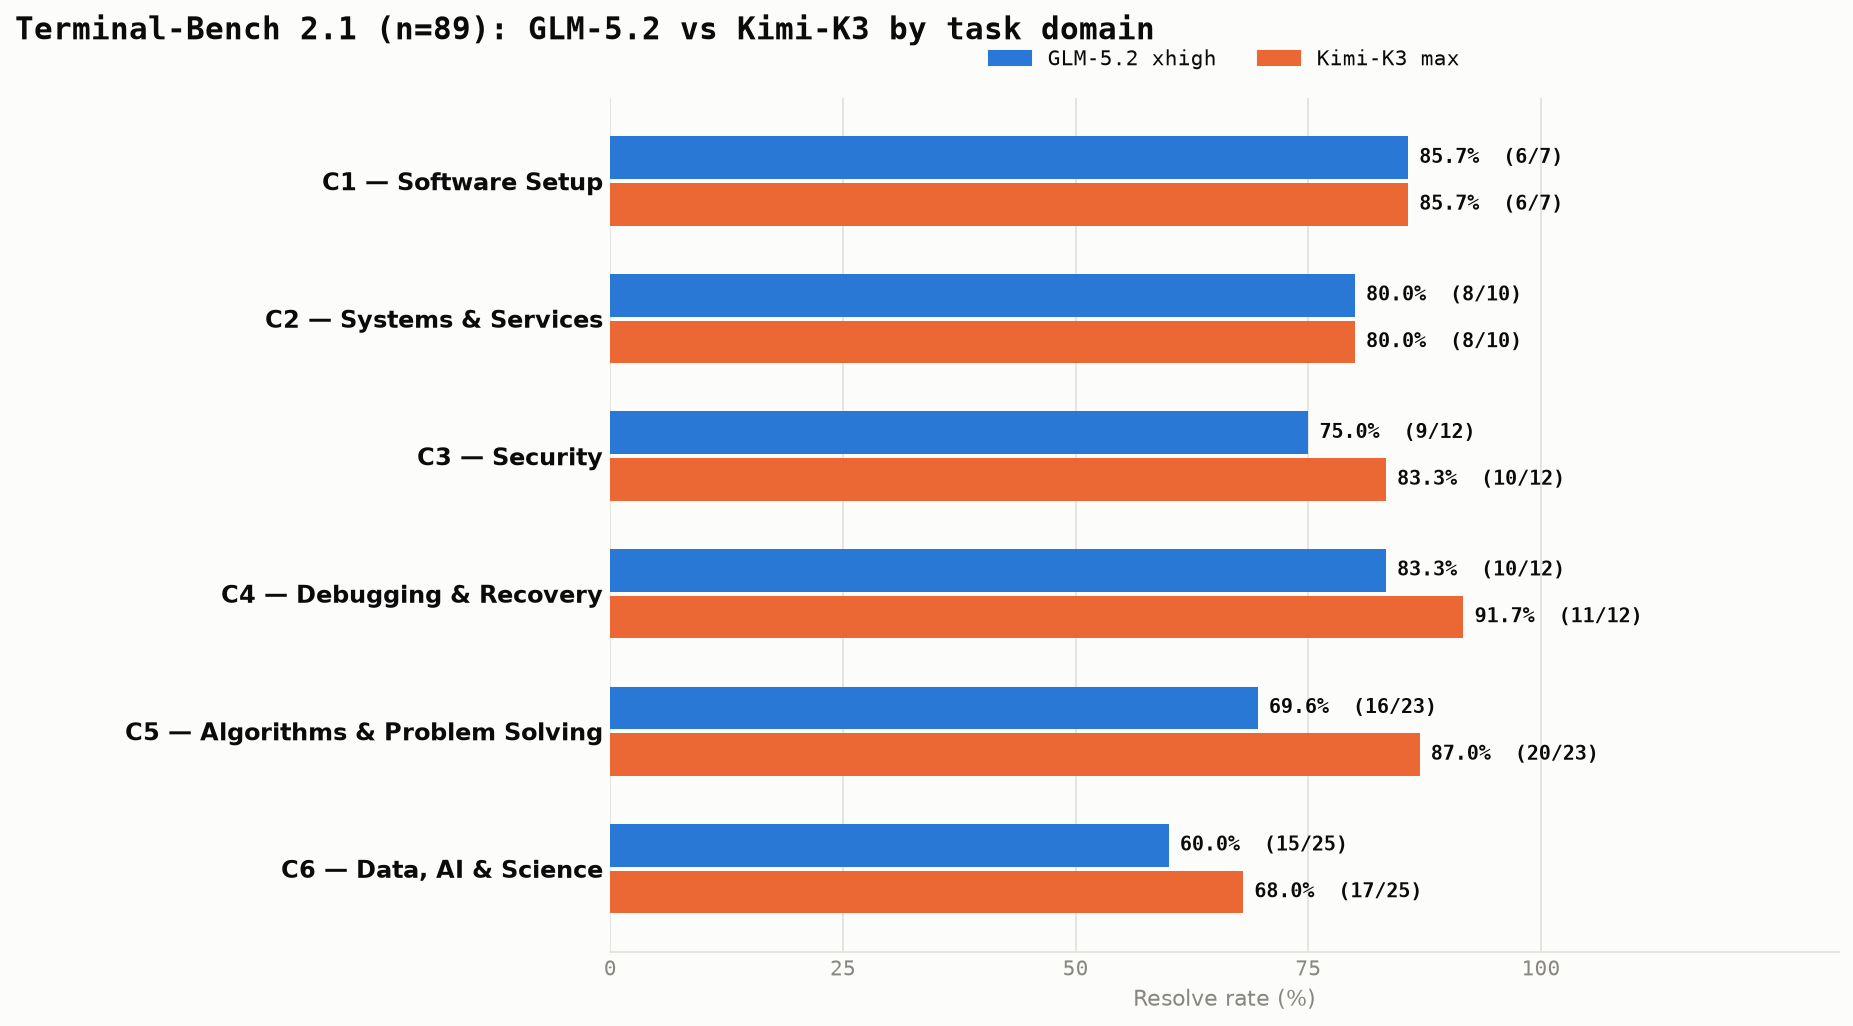

In [13]:
fig, ax = plt.subplots(figsize=(12.6, 7.4), dpi=150)
fig.patch.set_facecolor(SURFACE); ax.set_facecolor(SURFACE)

# Reverse so C1 reads at the top; barh renders the first item at the bottom.
tb_plot_domains = list(reversed(TB_CLASS_ORDER))
height = 0.34
offsets = [height / 2, -height / 2]
for yi, domain in enumerate(tb_plot_domains):
    for (model, config), offset in zip(MODELS.items(), offsets):
        row = tb_scores[(tb_scores.model == model) & (tb_scores.domain == domain)].iloc[0]
        ax.barh(yi + offset, row.rate_pct, height=height - 0.03, color=config['color'], zorder=3)
        ax.text(row.rate_pct + 1.2, yi + offset,
                f'{row.rate_pct:.1f}%  ({row.resolved}/{row.total})',
                va='center', ha='left', fontsize=9.5, color=INK,
                fontfamily=MONO, fontweight='bold')

ax.set_yticks(range(len(tb_plot_domains)))
ax.set_yticklabels(tb_plot_domains, fontsize=11.5, fontweight='bold', color=INK)
ax.set_xlim(0, 132); ax.set_xticks([0, 25, 50, 75, 100])
ax.set_xticklabels(['0', '25', '50', '75', '100'], fontsize=10, color=MUTED, fontfamily=MONO)
ax.set_xlabel('Resolve rate (%)', fontsize=10.5, color=MUTED)
ax.xaxis.grid(True, color=GRID, lw=0.8, zorder=0); ax.set_axisbelow(True)
for side in ('top', 'right', 'left'): ax.spines[side].set_visible(False)
ax.spines['bottom'].set_color(GRID); ax.tick_params(length=0)
ax.legend(handles=[Patch(color=config['color'], label=model) for model, config in MODELS.items()],
          loc='lower center', bbox_to_anchor=(0.5, 1.01), ncol=2,
          frameon=False, fontsize=11, prop={'family': MONO}, labelcolor=INK)
fig.text(0.005, 0.955, 'Terminal-Bench 2.1 (n=89): GLM-5.2 vs Kimi-K3 by task domain',
         fontsize=15, fontweight='bold', fontfamily=MONO, color=INK, va='top')
fig.subplots_adjust(left=0.32, right=0.97, top=0.88, bottom=0.11)

# out = REPO / 'notebooks/fig2_terminal_bench_2_1_domains.png'
# fig.savefig(out, facecolor=SURFACE, bbox_inches='tight')
# print(f'saved -> {out}')
plt.show()